In [1]:
from __future__ import annotations

from datetime import datetime
from pathlib import Path
from typing import TYPE_CHECKING

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from IPython.display import display
from ipywidgets import widgets
from scipy import signal as sig

if TYPE_CHECKING:
    from typing import TypeVar

    from numpy import double, float64, floating
    from numpy.typing import NBitBase, NDArray

    T = floating[TypeVar("T", bound=NBitBase)]


SCRIPT_DIR = Path().resolve()
DATA_DIR = SCRIPT_DIR / "../data/"

# dataset file names
VELOCITY_FILE = list(
    Path(DATA_DIR / "NH10_Mooring_Data").glob("nh10_hourly_data_1997_2021_part*.nc"),
)
VELOCITY_SAVE_FILE = Path(
    "NH10_Mooring_Data/nh10_hourly_data_1997_2021_rotated_filtered_streamwise.nc",
)


def princax(
    u: NDArray[double] | xr.DataArray,
    v: NDArray[double] | xr.DataArray,
) -> tuple[double, double, double]:
    """Determines the principal axis of variance for the east and north velocities defined by u and v

    Args:
        u (scalar or array): east velocity
        v (scalar or array): north velocity

    Returns:
        tuple of scalar: (theta, major, minor) - the angle of the principal axis CW from north,
            the variance along the major axis, and the variance along the minor axis

    """
    if isinstance(u, xr.DataArray):
        # convert to numpy array
        u = u.values
    if isinstance(v, xr.DataArray):
        v = v.values
    u = np.asarray(u)
    v = np.asarray(v)

    # only use finite values for covariance matrix
    ii = np.isfinite(u + v)
    uf = u[ii]
    vf = v[ii]

    # compute covariance matrix
    C = np.cov(uf, vf)

    # calculate principal axis angle (ET, Equation 4.3.23b)
    # > 0 CCW from east axis, < 0 CW from east axis
    theta = 0.5 * np.rad2deg(np.arctan2(2.0 * C[0, 1], (C[0, 0] - C[1, 1])))
    # switch to > 0 CW from north axis, < 0 CCW from north axis
    if theta >= 0:
        theta = 90 - theta
    elif theta < 0:
        theta = -(90 + theta)

    # calculate variance along major and minor axes (Equation 4.3.24)
    term1 = C[0, 0] + C[1, 1]
    term2 = ((C[0, 0] - C[1, 1]) ** 2 + 4 * (C[0, 1] ** 2)) ** 0.5
    major = np.sqrt(0.5 * (term1 + term2))
    minor = np.sqrt(0.5 * (term1 - term2))

    return theta, major, minor


def rot(
    u: NDArray[T] | xr.DataArray,
    v: NDArray[T] | xr.DataArray,
    theta: float | double | floating,
) -> tuple[NDArray[T], NDArray[T]]:
    """Rotates a vector counter clockwise or a coordinate system clockwise
    Designed to be used with theta output from princax(u, v)

    Args:
        u (scalar or array): x-component of vector
        v (scalar or array): y-component of vector
        theta (scalar): rotation angle (CCW > 0, CW < 0)

    Returns:
        tuple of scalar or array: (ur, vr) - x and y components of vector in rotated coordinate system

    """
    # convert to numpy array
    if isinstance(u, xr.DataArray):
        u = u.values
    if isinstance(v, xr.DataArray):
        v = v.values
    u = np.asarray(u)
    v = np.asarray(v)

    # rotate vector according to angle theta
    w = u + 1j * v
    ang = np.deg2rad(theta)
    wr = w * np.exp(1j * ang)
    ur = np.real(wr)
    vr = np.imag(wr)
    return ur, vr


velocity = xr.open_mfdataset(
    VELOCITY_FILE,
)
velocity = velocity.squeeze()
# rename for convienience
velocity = velocity.rename(
    {
        "eastward_velocity": "u",
        "northward_velocity": "v",
    },
)
# velocity = velocity.resample(time="1h").mean()

# get filtering weights for 40 hour low pass filter - assumes 1 hour time step in data
wts: NDArray[float64] = sig.firwin(101, 1 / 40, window="lanczos", fs=1)
# velocity = np.sqrt(velocity["u"].values ** 2 + velocity["v"].values ** 2)

# print(velocity["u"].values.shape)

# compute cross-shore and along-shore velocities based on principal axis of variance
evel_filt: NDArray[float64] = sig.filtfilt(wts, 1, velocity["u"].values, axis=1)
nvel_filt: NDArray[float64] = sig.filtfilt(wts, 1, velocity["v"].values, axis=1)
theta, major, minor = princax(
    np.nanmean(evel_filt, axis=1),
    np.nanmean(nvel_filt, axis=1),
)
cs_vel, as_vel = rot(evel_filt, nvel_filt, theta)
velocity["u_filt"] = (["depth", "time"], evel_filt)
velocity["v_filt"] = (["depth", "time"], nvel_filt)
velocity["cs"] = (["depth", "time"], cs_vel)
velocity["cs"] = velocity["cs"] - velocity["cs"].mean(
    dim="depth",
    keep_attrs=True,
)  # remove depth average

# compute cross-shore and along-shore velocities based on meandering along-shelf flow as in McCabe et al. (2015)
phi = np.arctan2(np.nanmean(as_vel, axis=0), np.nanmean(cs_vel, axis=0))
u_n = np.array(
    [-u * np.sin(p) + v * np.cos(p) for u, v, p in zip(cs_vel.T, as_vel.T, phi, strict=False)],
).T
u_p = np.array(
    [(np.dot(u_n, u) / np.dot(u, u)) * u for u, u_n in zip(cs_vel.T, u_n.T, strict=False)],
).T
# u_p[:, phi > 0] = -u_p[:, phi > 0]  # flip sign for positive phi
velocity["u_n"] = (["depth", "time"], u_n)
velocity["u_p"] = (["depth", "time"], u_p)

velocity["as"] = (["depth", "time"], as_vel)

# remove depth average from cross-shore velocity
velocity["cs_proj"] = (["depth", "time"], u_p)

C:\Users\asche\AppData\Local\Temp\ipykernel_61192\1247739332.py:151: RuntimeWarning: Mean of empty slice
  phi = np.arctan2(np.nanmean(as_vel, axis=0), np.nanmean(cs_vel, axis=0))


In [2]:
depth = widgets.Dropdown(
    options=velocity["depth"].values,
    value=velocity["depth"].values[0],
    description="Depth (m):",
    disabled=False,
    style={"description_width": "initial"},
)
display(depth)

Dropdown(description='Depth (m):', options=(np.float32(0.0), np.float32(2.0), np.float32(4.0), np.float32(6.0)…

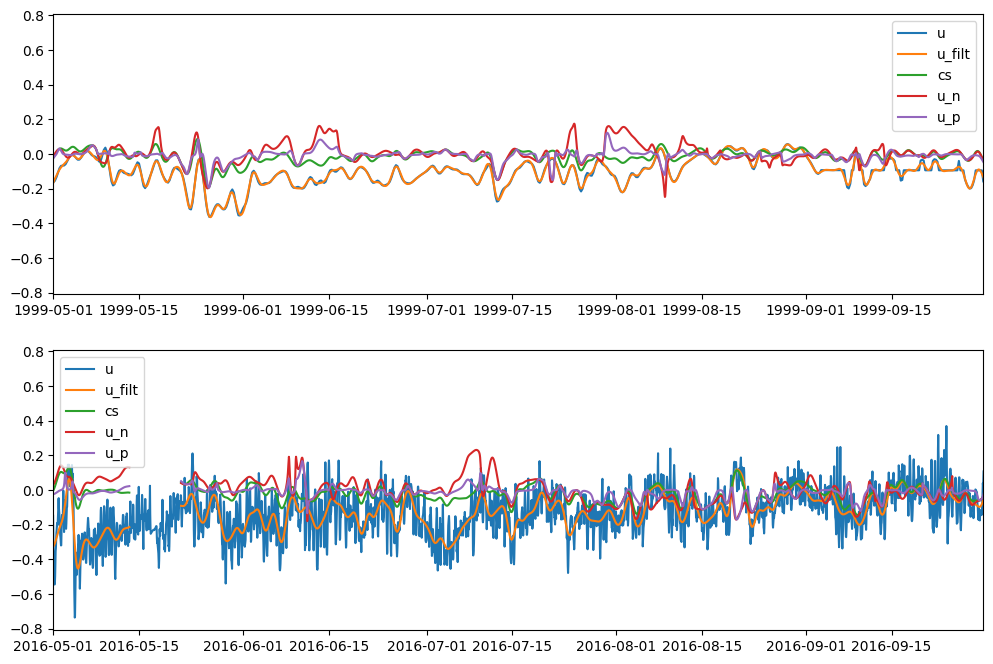

In [3]:
velocity_depth = velocity.sel(depth=depth.value)
fig, (ax1, ax2) = plt.subplots(2, 1, sharey=True, figsize=(12, 8))
ax1.plot(velocity.time, velocity_depth["u"], label="u")
ax1.plot(velocity.time, velocity_depth["u_filt"], label="u_filt")
ax1.plot(velocity.time, velocity_depth["cs"], label="cs")
ax1.plot(velocity.time, velocity_depth["u_n"], label="u_n")
ax1.plot(velocity.time, velocity_depth["u_p"], label="u_p")
# plt.plot(velocity.time, cs_vel[10], label="cs_vel")
# plt.plot(velocity.time, as_vel[10], label="cs_vel")
ax1.set_xlim(np.datetime64(datetime(1999, 5, 1)), np.datetime64(datetime(1999, 9, 30)))
ax1.legend()
ax2.plot(velocity.time, velocity_depth["u"], label="u")
ax2.plot(velocity.time, velocity_depth["u_filt"], label="u_filt")
ax2.plot(velocity.time, velocity_depth["cs"], label="cs")
ax2.plot(velocity.time, velocity_depth["u_n"], label="u_n")
ax2.plot(velocity.time, velocity_depth["u_p"], label="u_p")
# plt.plot(velocity.time, cs_vel[10], label="cs_vel")
# plt.plot(velocity.time, as_vel[10], label="cs_vel")
ax2.set_xlim(np.datetime64(datetime(2016, 5, 1)), np.datetime64(datetime(2016, 9, 30)))
ax2.legend()